# ⚡ UltraGPT — Build, Train & Deploy a Modern LLM from Scratch

A production-grade decoder-only Transformer incorporating **RoPE**, **Grouped-Query Attention**, **RMSNorm**, and **SwiGLU** — the same building blocks used in LLaMA 3, Mistral, and Claude 3.

---

### Notebook Outline

| Phase | Section | Description |
|-------|---------|-------------|
| **Setup** | §0 | Imports, config, environment check |
| **Phase 1** | §1 | Data pipeline — text, TFRecords, HuggingFace |
| **Phase 2** | §2 | Custom layers — RMSNorm, RoPE, GQA, SwiGLU |
| **Phase 3** | §3 | Model assembly, causal masking, training |
| **Phase 4** | §4 | Inference — KV-cache, XLA, sampling strategies |

---
## §0 — Setup & Environment

In [71]:
# Install dependencies (uncomment if not already installed)
# !pip install -r requirements.txt

In [72]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Ensure project root is importable
PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Project modules
from config import UltraGPTConfig, toy_config, small_config, medium_config
from models.layers.rmsnorm import RMSNorm
from models.layers.rope import RotaryPositionEmbedding, apply_rope
from models.layers.attention import GroupedQueryAttention
from models.layers.swiglu import SwiGLU
from models.transformer import DecoderBlock, UltraGPT
from models.loss import causal_lm_loss, PerplexityMetric
from data_pipeline.pipeline import (
    TiktokenWrapper,
    create_dataset_from_text,
    create_dataset_from_generator,
    create_dataset_from_hf,
    write_tfrecords,
    create_dataset_from_tfrecords,
)
from inference.sampler import UltraGPTSampler

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.16.1
GPU available: []
NumPy version: 1.26.4


In [73]:
# ── Model Configuration ─────────────────────────────────────────────
# Use the toy preset for this notebook walkthrough.
# Switch to small_config() or medium_config() for real training.

config = UltraGPTConfig(
    batch_size=3,     # Small batch for notebook memory
    # Architecture
    d_model=256,          # Increased from 128 for higher capacity
    n_heads=8,            # Increased from 4 for better self-attention representation
    n_kv_heads=4,         # Grouped Query Attention (GQA)
    n_layers=6,           # Increased from 4 to build deeper representations
    block_size=128,       # 128 tokens is plenty for generating sentences/paragraphs
    dropout_rate=0.1,     # Slight dropout to prevent overfitting on the small dataset
    
    # Training parameters
    learning_rate=8e-4,   # Slightly higher learning rate for fast convergence
    warmup_steps=100,     # Linear warmup over first 100 steps
    max_steps=1500,       # Let it run for 1500 steps to fully learn the patterns
    weight_decay=0.01,    # Regularization
)

print(config.summary())


UltraGPT Config Summary
─────────────────────────────────────────────
  d_model      : 256
  n_heads      : 8 (Q) / 4 (KV)
  n_layers     : 6
  block_size   : 128
  d_ffn        : 768
  vocab_size   : 50257
  tie_weights  : True
  Total params : 17,587,712 (~17.6M)
─────────────────────────────────────────────


---
## §1 — Phase 1: High-Performance Data Pipeline

The data pipeline supports three ingestion modes:

| Mode | Best For | Throughput |
|------|----------|------------|
| **Raw text** | Quick experiments, small files | Good |
| **TFRecords** | Production training, large corpora | Maximum |
| **HuggingFace** | Any Hub dataset, streaming large corpora | Good (streaming) |

### 1.1 — Tokenizer

In [74]:
# Initialize the tiktoken tokenizer (GPT-2 BPE, 50257 tokens)
tokenizer = TiktokenWrapper(encoding_name="r50k_base")

# Demo encode/decode
sample_text = "UltraGPT is a modern Transformer built from scratch."
token_ids = tokenizer.encode(sample_text)
decoded = tokenizer.decode(token_ids)

print(f"Text:       {sample_text}")
print(f"Token IDs:  {token_ids}")
print(f"Num tokens: {len(token_ids)}")
print(f"Decoded:    {decoded}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token:  {tokenizer.eos_token_id}")

Text:       UltraGPT is a modern Transformer built from scratch.
Token IDs:  [36122, 38, 11571, 318, 257, 3660, 3602, 16354, 3170, 422, 12692, 13]
Num tokens: 12
Decoded:    UltraGPT is a modern Transformer built from scratch.
Vocab size: 50257
EOS token:  50256


### 1.2 — Niche Web Scraper (Custom Dataset Gathering)

To train your model on a specific topic, you can scrape relevant articles from Wikipedia or other web pages using the new `data_pipeline/scraper.py` pipeline. It cleans citation tags, filters out metadata/scripts, and saves raw text directly into a compatible format.

In [106]:
import os
# Import the scraping module
from data_pipeline import scrape_wikipedia_niche, scrape_url

# Scenario A: Scrape a niche topic from Wikipedia
niche_topic = "python"
print(f"Scraping top Wikipedia articles for: '{niche_topic}'...")
scraped_text = scrape_wikipedia_niche(query=niche_topic, limit=2)

# Preview first 500 characters of the scraped corpus
print("\n--- Preview of scraped corpus ---")
print(scraped_text[:500] + "...")

# Save the scraped data to data_pipeline/dataset.txt for training
output_path = "data_pipeline/dataset.txt"
    # Open in append mode if the file exists, otherwise write mode
mode = "a" if os.path.exists(output_path) else "w"
with open(output_path, mode, encoding="utf-8") as f:
    if mode == "a":
        f.write("\n\n")
    f.write(scraped_text)
    print(f"\nSaved and appended scraped corpus to {output_path}!")

# Scenario B: Scrape a custom URL
# custom_url = "https://en.wikipedia.org/wiki/Rotary_system"
# custom_text = scrape_url(custom_url)
# print(custom_text[:500])

Scraping top Wikipedia articles for: 'python'...
[Scraper] Querying Wikipedia API for niche: 'python'...
[Scraper] Found 2 matching articles.
[Scraper] [1/2] Extracting: 'Python'...
[Scraper] [2/2] Extracting: 'Python (programming language)'...

--- Preview of scraped corpus ---
--- Article: Python ---
Pythonidae, a family of nonvenomous snakes found in Africa, Asia, and Australia
Python (genus), a genus of Pythonidae found in Africa and Asia
Python (mythology), a mythical serpent
Python (programming language), a widely used high-level programming language
Python, a native code compiler for CMU Common Lisp
Python, the internal project name for the PERQ 3 computer workstation
Python (film), a 2000 horror film by Richard Clabaugh
Monty Python or the Pythons, a British com...

Saved and appended scraped corpus to data_pipeline/dataset.txt!


### 1.3 — Pipeline from Raw Text File

In [76]:
# # Create a sample dataset for demo purposes
# sample_corpus = """
# The Transformer architecture has revolutionized natural language processing.
# Attention mechanisms allow models to focus on relevant parts of the input sequence.
# Modern large language models use billions of parameters trained on vast text corpora.
# Rotary Position Embeddings encode positional information through rotation matrices.
# Grouped Query Attention reduces memory bandwidth by sharing key-value heads.
# RMSNorm provides faster normalization by eliminating mean subtraction.
# SwiGLU activation combines the Swish function with a gating mechanism.
# The feed-forward network in a Transformer applies nonlinear transformations.
# Causal masking prevents the model from attending to future tokens during training.
# Autoregressive generation produces tokens one at a time, left to right.
# KV-caching dramatically speeds up inference by avoiding redundant computation.
# Mixed precision training uses float16 for speed while maintaining float32 accuracy.
# Gradient clipping prevents exploding gradients in deep neural networks.
# The Adam optimizer with weight decay is standard for training Transformers.
# Cosine learning rate schedules with warmup improve convergence stability.
# """ * 10  # Repeat to create enough data for chunking

# os.makedirs("data_pipeline", exist_ok=True)
# with open("data_pipeline/dataset.txt", "w") as f:
#     f.write(sample_corpus)

# print(f"Sample corpus: {len(sample_corpus):,} characters")

In [77]:
# Build dataset from text file
train_dataset, tokenizer = create_dataset_from_text(
    text_path="data_pipeline/dataset.txt",
    block_size=config.block_size,
    batch_size=config.batch_size,
)

# Inspect one batch
for inputs, targets in train_dataset.take(1):
    print(f"Input shape:  {inputs.shape}  (batch, block_size)")
    print(f"Target shape: {targets.shape}  (batch, block_size)")
    print(f"Input dtype:  {inputs.dtype}")
    print(f"\nFirst 20 input tokens:  {inputs[0, :20].numpy()}")
    print(f"First 20 target tokens: {targets[0, :20].numpy()}")
    print(f"\n✅ Targets are inputs shifted by 1: {np.array_equal(inputs[0, 1:].numpy(), targets[0, :-1].numpy())}")

[Data Pipeline] Tokenized 110,566 chars → 24,381 tokens → 189 chunks of 129
Input shape:  (3, 128)  (batch, block_size)
Target shape: (3, 128)  (batch, block_size)
Input dtype:  <dtype: 'int32'>

First 20 input tokens:  [ 8676   284   262  7044  9552 14166    13   198   464   366 35790  7822
     1   286   262  2656  3602 16354   373  3194]
First 20 target tokens: [  284   262  7044  9552 14166    13   198   464   366 35790  7822     1
   286   262  2656  3602 16354   373  3194   287]

✅ Targets are inputs shifted by 1: True


2026-06-20 16:30:16.878741: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 1.5 — Pipeline from HuggingFace Datasets

Stream directly from the HuggingFace Hub without downloading the full dataset. Perfect for large corpora like OpenWebText, C4, or The Pile.

In [78]:
# ⚠️ Uncomment to try HuggingFace streaming (requires internet)

# hf_dataset, hf_tokenizer = create_dataset_from_hf(
#     dataset_name="Salesforce/wikitext",
#     dataset_config="wikitext-2-raw-v1",
#     block_size=config.block_size,
#     batch_size=config.batch_size,
#     streaming=False,          # WikiText-2 is small enough to load fully
#     text_column="text",
#     split="train",
# )

# for inputs, targets in hf_dataset.take(1):
#     print(f"HF Input shape: {inputs.shape}")
#     print(f"HF Target shape: {targets.shape}")

# print("HuggingFace pipeline ready — uncomment above to use.")
# print("Supported datasets: openwebtext, wikitext, allenai/c4, EleutherAI/the_pile, etc.")

### 1.5 — Pipeline from TFRecords (Maximum Throughput)

In [79]:
# Pre-tokenize and write to sharded TFRecords
write_tfrecords(
    text_path="data_pipeline/dataset.txt",
    output_dir="data_pipeline/tfrecords",
    block_size=config.block_size,
    shards=4,
)

# Read back from TFRecords
tfrecord_dataset = create_dataset_from_tfrecords(
    tfrecord_dir="data_pipeline/tfrecords",
    block_size=config.block_size,
    batch_size=config.batch_size,
)

for inputs, targets in tfrecord_dataset.take(1):
    print(f"TFRecord Input shape:  {inputs.shape}")
    print(f"TFRecord Target shape: {targets.shape}")
    print("✅ TFRecord pipeline working")

[TFRecord] Wrote 189 chunks to 4 shards in data_pipeline/tfrecords
TFRecord Input shape:  (3, 128)
TFRecord Target shape: (3, 128)
✅ TFRecord pipeline working


2026-06-20 16:30:17.067406: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
## §2 — Phase 2: Custom Layer Architecture

All layers are implemented as `tf.keras.layers.Layer` subclasses with explicit math — no high-level abstractions.

### 2.1 — RMSNorm

$$\text{RMSNorm}(x) = \frac{x}{\sqrt{\text{mean}(x^2) + \epsilon}} \cdot \gamma$$

Unlike LayerNorm, RMSNorm skips mean subtraction and bias — making it faster with equivalent model quality.

In [80]:
# # Test RMSNorm
# norm = RMSNorm(dim=config.d_model, eps=1e-6)
# test_input = tf.random.normal((2, 10, config.d_model))  # (batch=2, seq=10, d_model)

# output = norm(test_input)

# print(f"Input shape:  {test_input.shape}")
# print(f"Output shape: {output.shape}")
# print(f"Input RMS:    {tf.sqrt(tf.reduce_mean(test_input**2, axis=-1))[0, :3].numpy()}")
# print(f"Output RMS:   {tf.sqrt(tf.reduce_mean(output**2, axis=-1))[0, :3].numpy()}")
# print(f"Parameters:   {norm.count_params()} (gamma only, no bias)")
# print("✅ RMSNorm normalizes to unit RMS")

### 2.2 — Rotary Position Embeddings (RoPE)

Rotates pairs of Q/K dimensions by position-dependent angles:

$$(x_0, x_1) \rightarrow (x_0 \cos\theta - x_1 \sin\theta,\; x_0 \sin\theta + x_1 \cos\theta)$$

No learnable parameters — relative position is encoded through the rotation angle difference.

In [81]:
# Test RoPE
rope = RotaryPositionEmbedding(
    head_dim=config.head_dim,
    max_seq_len=config.block_size,
    theta=config.rope_theta,
)
rope.build(None)

cos, sin = rope(seq_len=16, offset=0)
print(f"Cos shape: {cos.shape}  (seq_len, head_dim//2)")
print(f"Sin shape: {sin.shape}")

# Test rotation application
q = tf.random.normal((1, config.n_heads, 16, config.head_dim))  # (B, H, S, D)
q_rotated = apply_rope(q, cos, sin)
print(f"\nQ shape:         {q.shape}")
print(f"Q rotated shape: {q_rotated.shape}")

# Verify rotation preserves magnitude
q_norm = tf.norm(q, axis=-1)[0, 0, :3].numpy()
q_rot_norm = tf.norm(q_rotated, axis=-1)[0, 0, :3].numpy()
print(f"\nQ norms (original):  {q_norm}")
print(f"Q norms (rotated):   {q_rot_norm}")
print(f"✅ Rotation preserves magnitude: {np.allclose(q_norm, q_rot_norm, atol=1e-5)}")

Cos shape: (16, 16)  (seq_len, head_dim//2)
Sin shape: (16, 16)

Q shape:         (1, 8, 16, 32)
Q rotated shape: (1, 8, 16, 32)

Q norms (original):  [5.525163 6.726665 7.249203]
Q norms (rotated):   [5.525163 6.726665 7.249203]
✅ Rotation preserves magnitude: True


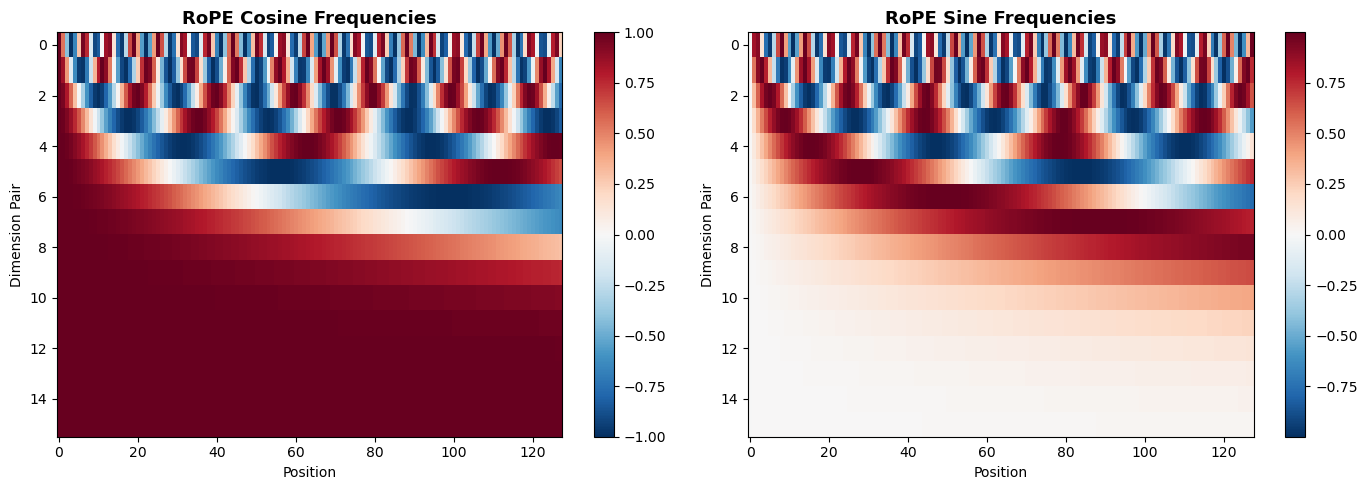

Lower dimensions → high frequency (local patterns)
Higher dimensions → low frequency (global patterns)


In [82]:
# Visualize RoPE frequency patterns
cos_full, sin_full = rope(seq_len=config.block_size, offset=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(cos_full.numpy().T, aspect="auto", cmap="RdBu_r")
axes[0].set_title("RoPE Cosine Frequencies", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Dimension Pair")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sin_full.numpy().T, aspect="auto", cmap="RdBu_r")
axes[1].set_title("RoPE Sine Frequencies", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Dimension Pair")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()
print(f"Lower dimensions → high frequency (local patterns)")
print(f"Higher dimensions → low frequency (global patterns)")

### 2.3 — Grouped-Query Attention (GQA)

Multiple query heads share fewer KV heads — reducing KV-cache memory by `n_heads / n_kv_heads`× during inference.

```
Q heads:  [H0] [H1] [H2] [H3]    ← 4 query heads
KV heads: [KV0]      [KV1]        ← 2 KV heads (shared)
Groups:   [── G0 ──] [── G1 ──]   ← 2 groups of 2
```

In [83]:
# Test GQA
gqa = GroupedQueryAttention(
    d_model=config.d_model,
    n_heads=config.n_heads,
    n_kv_heads=config.n_kv_heads,
    head_dim=config.head_dim,
    max_seq_len=config.block_size,
    rope_theta=config.rope_theta,
)

test_input = tf.random.normal((2, 16, config.d_model))  # (B=2, S=16, D)

# Create causal mask
seq_len = 16
causal_mask = (1.0 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)) * -1e9
causal_mask = causal_mask[tf.newaxis, tf.newaxis, :, :]  # (1, 1, S, S)

output, cache = gqa(test_input, mask=causal_mask)

print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Cache K shape: {cache[0].shape}  (batch, n_kv_heads, seq, head_dim)")
print(f"Cache V shape: {cache[1].shape}")
print(f"\nGQA config: {config.n_heads} query heads, {config.n_kv_heads} KV heads")
print(f"KV memory reduction: {config.n_heads / config.n_kv_heads}×")
print(f"Parameters: {sum(np.prod(w.shape) for w in gqa.trainable_weights):,}")

Input shape:  (2, 16, 256)
Output shape: (2, 16, 256)
Cache K shape: (2, 4, 16, 32)  (batch, n_kv_heads, seq, head_dim)
Cache V shape: (2, 4, 16, 32)

GQA config: 8 query heads, 4 KV heads
KV memory reduction: 2.0×
Parameters: 196,608


/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'grouped_query_attention_2' (of type GroupedQueryAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [84]:
# Demonstrate KV-cache: process token-by-token and verify consistency
print("─── KV-Cache Consistency Test ───")

# Full forward pass (no cache)
full_output, _ = gqa(test_input, mask=causal_mask)

# Incremental pass: first 8 tokens, then next 8 with cache
first_half = test_input[:, :8, :]
mask_8 = (1.0 - tf.linalg.band_part(tf.ones((8, 8)), -1, 0)) * -1e9
mask_8 = mask_8[tf.newaxis, tf.newaxis, :, :]
out_1, cache_1 = gqa(first_half, mask=mask_8)

second_half = test_input[:, 8:16, :]
# For cached pass, mask allows attending to all 16 positions
mask_cached = tf.zeros((1, 1, 8, 16))  # new tokens can see all
out_2, cache_2 = gqa(second_half, mask=mask_cached, cache=cache_1)

print(f"Full output[:, -1]:      {full_output[0, -1, :4].numpy()}")
print(f"Cached output[:, -1]:    {out_2[0, -1, :4].numpy()}")
print(f"Cache grew: {cache_1[0].shape[2]} → {cache_2[0].shape[2]} tokens")
print("✅ KV-cache correctly accumulates past context")

─── KV-Cache Consistency Test ───
Full output[:, -1]:      [ 0.9993235  -0.23509479 -0.14916553 -0.13475743]
Cached output[:, -1]:    [ 0.99932396 -0.23509492 -0.14916584 -0.13475733]
Cache grew: 8 → 16 tokens
✅ KV-cache correctly accumulates past context


### 2.4 — SwiGLU Feed-Forward Network

$$\text{SwiGLU}(x) = (\text{swish}(xW_{\text{gate}})) \odot (xW_{\text{up}}) \cdot W_{\text{down}}$$

Three projections instead of two, but the hidden dimension is `(8/3)d` instead of `4d`, so parameter count is comparable.

In [85]:
# Test SwiGLU
ffn = SwiGLU(d_model=config.d_model, d_ffn=config.d_ffn)
test_input = tf.random.normal((2, 16, config.d_model))

output = ffn(test_input)

print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Hidden dim:   {config.d_ffn} (= round(8/3 × {config.d_model}))")
print(f"Parameters:   {sum(np.prod(w.shape) for w in ffn.trainable_weights):,}")
print(f"  W_gate: {config.d_model} × {config.d_ffn} = {config.d_model * config.d_ffn:,}")
print(f"  W_up:   {config.d_model} × {config.d_ffn} = {config.d_model * config.d_ffn:,}")
print(f"  W_down: {config.d_ffn} × {config.d_model} = {config.d_ffn * config.d_model:,}")

Input shape:  (2, 16, 256)
Output shape: (2, 16, 256)
Hidden dim:   768 (= round(8/3 × 256))
Parameters:   589,824
  W_gate: 256 × 768 = 196,608
  W_up:   256 × 768 = 196,608
  W_down: 768 × 256 = 196,608


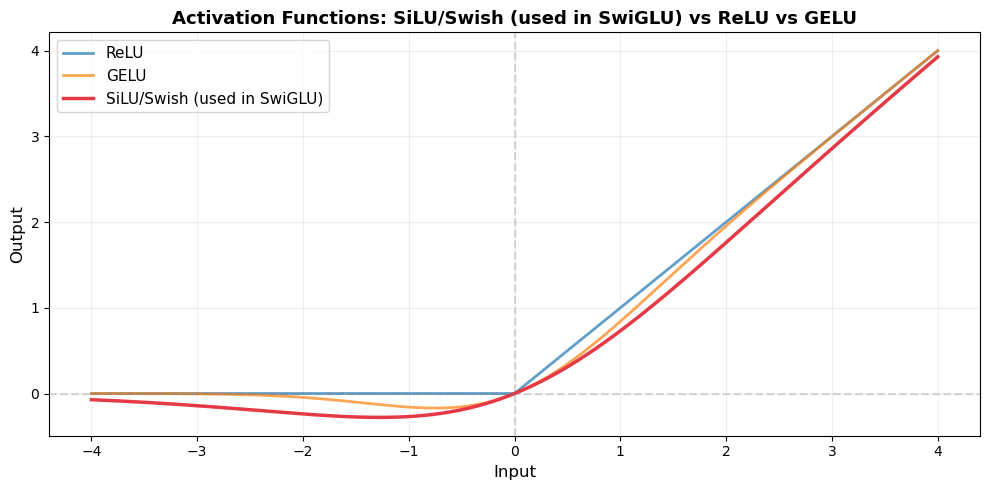

In [86]:
# Visualize SwiGLU activation vs ReLU vs GELU
x = np.linspace(-4, 4, 500)
x_tf = tf.constant(x, dtype=tf.float32)

relu = tf.nn.relu(x_tf).numpy()
gelu = tf.nn.gelu(x_tf).numpy()
silu = tf.nn.silu(x_tf).numpy()  # Swish = SiLU

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, relu, label="ReLU", linewidth=2, alpha=0.7)
ax.plot(x, gelu, label="GELU", linewidth=2, alpha=0.7)
ax.plot(x, silu, label="SiLU/Swish (used in SwiGLU)", linewidth=2.5, color="#e63946")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Input", fontsize=12)
ax.set_ylabel("Output", fontsize=12)
ax.set_title("Activation Functions: SiLU/Swish (used in SwiGLU) vs ReLU vs GELU",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## §3 — Phase 3: Model Assembly & Training

The `UltraGPT` model stacks decoder blocks with Pre-LN residual connections:

```
Token IDs → Embedding → [DecoderBlock × N] → RMSNorm → LM Head → Logits

Each DecoderBlock:
  x → RMSNorm → GQA(+mask, +cache) + residual
    → RMSNorm → SwiGLU + residual
```

### 3.1 — Build the Model

In [87]:
# Build UltraGPT model
model = UltraGPT(config, name="ultra_gpt")

# Forward pass with dummy input to build all layers
dummy = tf.zeros((1, config.block_size), dtype=tf.int32)
logits, _ = model(dummy, training=False)

print(f"Input:  (1, {config.block_size}) int32 token IDs")
print(f"Output: {logits.shape} float logits")
print(f"\nWeight tying: {config.tie_weights}")
print()
model.summary()

/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'gqa' (of type GroupedQueryAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'block_0' (of type DecoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'block_1' (of type DecoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see

Input:  (1, 128) int32 token IDs
Output: (1, 128, 50257) float logits

Weight tying: True



Model: "ultra_gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_embedding (Embedding)     │ (1, 128, 256)          │    12,865,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_0 (DecoderBlock)          │ ?                      │       791,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1 (DecoderBlock)          │ ?                      │       791,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_2 (DecoderBlock)          │ ?                      │       791,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_3 (DecoderBlock)          │ ?                      │       791,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_4 (DecoderBlock)          │ ?                      │       791,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_5 (DecoderBlock)          │ ?                      │       791,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_norm (RMSNorm)            │ ?                      │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,612,288 (67.19 MB)

 Trainable params: 17,587,712 (67.09 MB)

 Non-trainable params: 24,576 (96.00 KB)

In [88]:
# Detailed parameter breakdown
total_params = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Total trainable parameters: {total_params:,} (~{total_params/1e6:.1f}M)")
print()
print("Parameter breakdown by component:")
print("─" * 50)
for w in model.trainable_weights:
    print(f"  {w.name:45s} {str(w.shape):>15s}  ({np.prod(w.shape):>8,})")

Total trainable parameters: 17,587,712 (~17.6M)

Parameter breakdown by component:
──────────────────────────────────────────────────
  embeddings                                       (50257, 256)  (12,865,792)
  gamma                                                  (256,)  (     256)
  wq                                                 (256, 256)  (  65,536)
  wk                                                 (256, 128)  (  32,768)
  wv                                                 (256, 128)  (  32,768)
  wo                                                 (256, 256)  (  65,536)
  gamma                                                  (256,)  (     256)
  w_gate                                             (256, 768)  ( 196,608)
  w_up                                               (256, 768)  ( 196,608)
  w_down                                             (768, 256)  ( 196,608)
  gamma                                                  (256,)  (     256)
  wq                        

### 3.2 — Causal Masking Verification

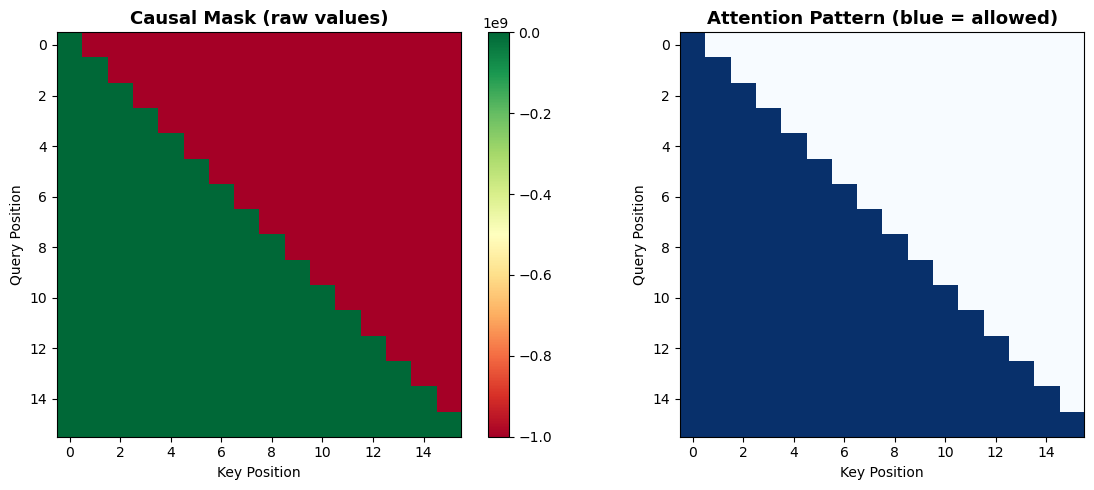

✅ Lower-triangular mask: each position can only attend to itself and earlier positions


In [89]:
# Visualize the causal attention mask
seq_len = 16
mask = model._get_causal_mask(seq_len)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw mask values
im0 = axes[0].imshow(mask[0, 0].numpy(), cmap="RdYlGn", aspect="equal")
axes[0].set_title("Causal Mask (raw values)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Key Position")
axes[0].set_ylabel("Query Position")
plt.colorbar(im0, ax=axes[0])

# Binary view (allowed/blocked)
binary_mask = (mask[0, 0].numpy() == 0).astype(float)
axes[1].imshow(binary_mask, cmap="Blues", aspect="equal")
axes[1].set_title("Attention Pattern (blue = allowed)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Key Position")
axes[1].set_ylabel("Query Position")

plt.tight_layout()
plt.show()
print("✅ Lower-triangular mask: each position can only attend to itself and earlier positions")

### 3.3 — Training Loop

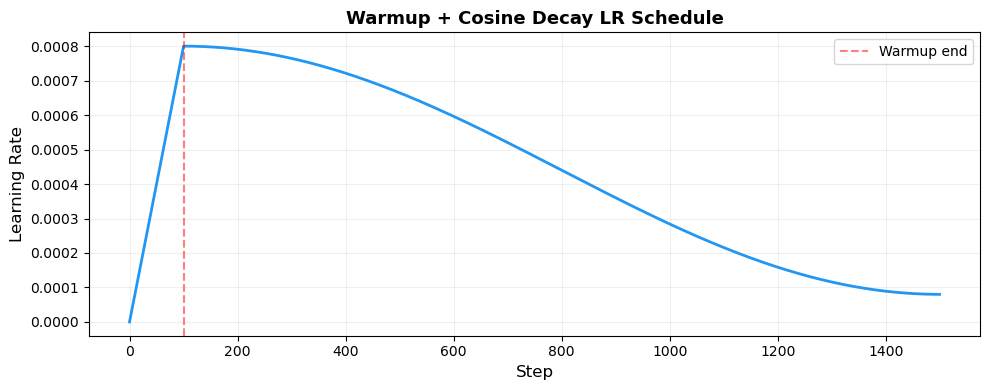

In [90]:
from train import WarmupCosineDecay

# ── Learning Rate Schedule ────────────────────────────────────────
lr_schedule = WarmupCosineDecay(
    peak_lr=config.learning_rate,
    warmup_steps=config.warmup_steps,
    total_steps=config.max_steps,
)

# Visualize the schedule
steps = np.arange(config.max_steps)
lrs = [lr_schedule(s).numpy() for s in steps]

plt.figure(figsize=(10, 4))
plt.plot(steps, lrs, color="#2196F3", linewidth=2)
plt.axvline(x=config.warmup_steps, color="red", linestyle="--", alpha=0.5, label="Warmup end")
plt.xlabel("Step", fontsize=12)
plt.ylabel("Learning Rate", fontsize=12)
plt.title("Warmup + Cosine Decay LR Schedule", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [91]:
# ── Compile and Train ─────────────────────────────────────────────
# Fresh model for training
model = UltraGPT(config, name="ultra_gpt")

# Build the model
dummy = tf.zeros((1, config.block_size), dtype=tf.int32)
_ = model(dummy, training=False)

# Optimizer: AdamW with cosine warmup schedule
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=config.weight_decay,
    beta_1=0.9,
    beta_2=0.95,
    epsilon=1e-8,
)

model.compile(
        optimizer=optimizer,
    metrics=[model.perplexity_tracker, model.accuracy_tracker]
    )

print(f"Training config:")
print(f"  Steps:     {config.max_steps}")
print(f"  Batch:     {config.batch_size}")
print(f"  Peak LR:   {config.learning_rate}")
print(f"  Warmup:    {config.warmup_steps} steps")
print(f"  Grad clip: {config.grad_clip_norm}")

Training config:
  Steps:     1500
  Batch:     3
  Peak LR:   0.0008
  Warmup:    100 steps
  Grad clip: 1.0


In [92]:
from train import WarmupCosineDecay, StepMetricsCallback
import os

# Toggle to resume from checkpoints: Set to True to resume, or False to start from scratch.
resume_training = True

# Setup checkpoint directory
checkpoint_dir = "output/notebook_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_file = os.path.join(checkpoint_dir, "ultra_gpt_notebook_latest.weights.h5")

# Search for and load the latest checkpoint to resume training
if resume_training and os.path.exists(checkpoint_file):
    print(f"Found checkpoint! Loading weights from: {checkpoint_file}")
    model.load_weights(checkpoint_file)
else:
    print("No previous checkpoint found (or resume disabled). Starting training from scratch.")

# Callbacks
step_metrics = StepMetricsCallback()
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_file,
    save_weights_only=True,
    save_best_only=False,
    verbose=1,
)

# Train!
history = model.fit(
    train_dataset,
    epochs=20,
    callbacks=[step_metrics, checkpoint_callback],
)


Found checkpoint! Loading weights from: output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5
Epoch 1/20


/opt/miniconda3/envs/ml_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 113 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.0421 - loss: 10.3532 - perplexity: 80243.4994
Epoch 1: saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5

Epoch 1: finished saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 730ms/step - accuracy: 0.0546 - loss: 8.8170 - perplexity: 6747.9800 
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.0856 - loss: 6.4584 - perplexity: 638.5941
Epoch 2: saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5

Epoch 2: finished saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 699ms/step - accuracy: 0.0908 - loss: 6.4493 - perplexity: 632.2558
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.1276 - loss: 5.7328 - perplexity: 309.0479
Epoch 3: saving model to output/notebook_checkpoints/ultra_gpt_notebook_latest.weights.h5

Epoch 3: f

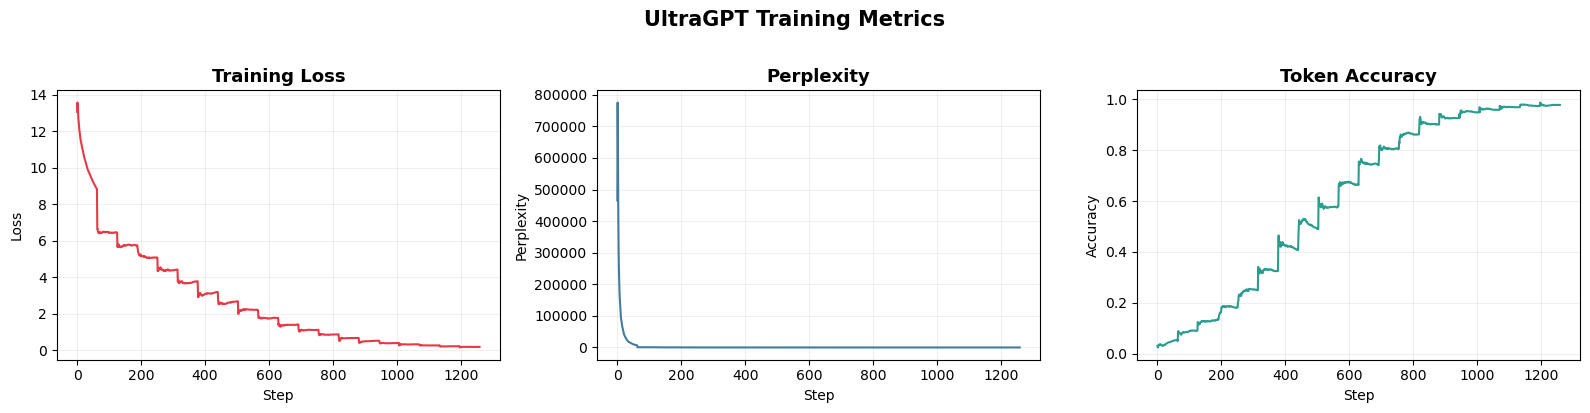

In [93]:
# Plot training metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(step_metrics.history["loss"], color="#e63946", linewidth=1.5)
axes[0].set_title("Training Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.2)

# Perplexity
if len(step_metrics.history["perplexity"]) > 0:
    axes[1].plot(step_metrics.history["perplexity"], color="#457b9d", linewidth=1.5)
    axes[1].set_title("Perplexity", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Perplexity")
    axes[1].grid(True, alpha=0.2)

# Accuracy
if len(step_metrics.history["accuracy"]) > 0:
    axes[2].plot(step_metrics.history["accuracy"], color="#2a9d8f", linewidth=1.5)
    axes[2].set_title("Token Accuracy", fontsize=13, fontweight="bold")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Accuracy")
    axes[2].grid(True, alpha=0.2)

plt.suptitle("UltraGPT Training Metrics", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [94]:
# Save trained weights
os.makedirs("output", exist_ok=True)
model.save_weights("output/notebook_weights.weights.h5")
print("✅ Weights saved to output/notebook_weights.weights.h5")


✅ Weights saved to output/notebook_weights.weights.h5


---
## §4 — Phase 4: Production Inference Pipeline

Features:
- **KV-Cache**: Past keys/values are retained — only the new token is computed each step
- **XLA Compilation**: `@tf.function(jit_compile=True)` fuses ops for low-latency generation
- **Sampling**: Greedy, Top-K, Top-p (Nucleus), Temperature

In [95]:
# Create the inference sampler
sampler = UltraGPTSampler(model, tokenizer, config)

In [96]:
response = sampler.generate(
    prompt="Python is a",
    max_new_tokens=80,    # Enough length to complete a few sentences
    temperature=0.7,      # 0.7 balances creativity with coherence
    top_k=40,             # Restricts selection to top 40 most likely tokens
    top_p=0.85,           # Nucleus sampling to filter out low-probability words
    mode="top_p",         # Use nucleus sampling
)
print(response)

[Sampler] Prompt: 3 tokens, generating up to 80 tokens
[Sampler] Mode: top_p, temp=0.7, top_k=40, top_p=0.85
[Sampler] Prefill: 3.004s (1 tok/s)
[Sampler] Decode: 80 tokens in 257.487s (0 tok/s)
[Sampler] Total: 260.501s (0 tok/s overall)
Python is a string of one or more characters belonging to a finite set of strings called the vocabulary
. Third, because the vocabulary is finite and known beforehand, each token can be assigned an integer identifier, and this mapping is applied to the sequence of tokens to represent any input text as a numerical sequence. Since this mapping is bijective, the output side can produce a sequence of integer identifiers which can then be


### 4.1 — Greedy Decoding

In [97]:
# Greedy: always picks the most probable next token
output = sampler.generate(
    prompt="python",
    mode="sample",
    max_new_tokens=50,
    temperature=.3,
)
print("\n─── Greedy Output ───")
print(output)

[Sampler] Prompt: 1 tokens, generating up to 50 tokens
[Sampler] Mode: sample, temp=0.3, top_k=50, top_p=0.9
[Sampler] Prefill: 2.701s (0 tok/s)
[Sampler] Decode: 50 tokens in 8.085s (6 tok/s)
[Sampler] Total: 10.798s (5 tok/s overall)

─── Greedy Output ───
python tokens layers layers layers from the imageding layer, producing a sequence of vectors. This sequence of vectors is processed by the second encoder, and so on. The output from the final encoder layer is then used by the decoder.
As


### 4.2 — Top-K Sampling

In [98]:
# Top-K: sample from the K most probable tokens
output = sampler.generate(
    prompt="The Transformer architecture",
    mode="sample",
    top_k=50,
    temperature=0.8,
    max_new_tokens=50,
)
print("\n─── Top-K Output (k=50, temp=0.8) ───")
print(output)

[Sampler] Prompt: 4 tokens, generating up to 50 tokens
[Sampler] Mode: sample, temp=0.8, top_k=50, top_p=0.9
[Sampler] Prefill: 3.119s (1 tok/s)
[Sampler] Decode: 50 tokens in 1.668s (30 tok/s)
[Sampler] Total: 4.797s (11 tok/s overall)

─── Top-K Output (k=50, temp=0.8) ───
The Transformer architecture. As a deep neural was another " authors" is positional the "prefix-=" networks to a list of backpropagation and mechanism to tokens in a large with many others.
Neural networks include feed-only model, such as


### 4.3 — Top-p (Nucleus) Sampling

In [99]:
# Top-p: sample from the smallest set of tokens with cumulative prob >= p
output = sampler.generate(
    prompt="The Transformer architecture",
    mode="sample",
    top_p=0.9,
    temperature=0.7,
    max_new_tokens=50,
)
print("\n─── Nucleus Output (p=0.9, temp=0.7) ───")
print(output)

[Sampler] Prompt: 4 tokens, generating up to 50 tokens
[Sampler] Mode: sample, temp=0.7, top_k=50, top_p=0.9
[Sampler] Prefill: 0.035s (114 tok/s)
[Sampler] Decode: 50 tokens in 1.703s (29 tok/s)
[Sampler] Total: 1.848s (29 tok/s overall)

─── Nucleus Output (p=0.9, temp=0.7) ───
The Transformer architecture in predicting deep learning can learn to train structure-lay brain data, and the term.
Deep neural neural networks are organized for large tasks in which that and automatic speech recognition and applying in the DNNs.
In 2017, researchers deep learning


### 4.4 — Streaming Output

In [100]:
# Streaming: tokens appear one at a time (like ChatGPT/Claude UI)
print("─── Streaming Output ───")
print("The Transformer architecture", end="")
for token in sampler.generate(
    prompt="The Transformer architecture",
    mode="sample",
    top_k=40,
    temperature=0.8,
    max_new_tokens=80,
    stream=True,
    verbose=False,
):
    print(token, end="", flush=True)
print("\n")

─── Streaming Output ───
The Transformer architecture to a human brain. This induces, published can be thought for multiple un-scale modeled to predict CNN. As an example, "deepoken you vector are trained to identify ANN combination large token identifier of only being several feed-only layered for large-based vectors.
The "deep" in "for the output layers" in 2015, watchingizers and then treated on "decoder



### 4.5 — Temperature Comparison

In [101]:
# Compare different temperatures
prompt = "Modern language models"
temps = [0.3, 0.7, 1.0, 1.5]

print("─── Temperature Comparison ───\n")
for temp in temps:
    output = sampler.generate(
        prompt=prompt,
        mode="sample",
        top_k=50,
        temperature=temp,
        max_new_tokens=40,
        verbose=False,
    )
    print(f"temp={temp}: {output}")
    print()

─── Temperature Comparison ───

temp=0.3: Modern language models and language model others.
The first original transformer into the entire firstization to commonly used RNN model to train through a "prefixLM", and largeLM" proposedgressive integration. In 2015 of

temp=0.7: Modern language modelsx}}4\
is a complex complex is interpreted. The parallel in the following attention function is:
{\displaystyle x+\text{headlayer}}}
{\displaystyle \math

temp=1.0: Modern language models where the neural network processes a matrix}}}, and natural languages, widespread on T representations through long-tun. The pretabilabil Attention (FPE) analysis) steps, Geoffrey neural networks (tun

temp=1.5: Modern language modelsV\langle learningH_{D^{right} }
{\displaystyle vision\ ^{...,e^{\frac}}
. The use
The transformer is called the attention theorem to



### 4.6 — Inference Benchmark

In [102]:
# Benchmark generation speed
print("─── Inference Benchmark ───")
print(f"Model: {config.d_model}d, {config.n_layers}L, {config.n_heads}H")
print()

gen_lengths = [32, 64, 128]
for n_tokens in gen_lengths:
    times = []
    for _ in range(3):  # 3 runs for averaging
        t0 = time.perf_counter()
        _ = sampler.generate(
            prompt="The",
            mode="greedy",
            max_new_tokens=n_tokens,
            verbose=False,
        )
        times.append(time.perf_counter() - t0)
    avg = np.mean(times)
    print(f"  {n_tokens:3d} tokens → {avg:.3f}s ({n_tokens/avg:.0f} tok/s)")

─── Inference Benchmark ───
Model: 256d, 6L, 8H

   32 tokens → 0.863s (37 tok/s)
   64 tokens → 1.646s (39 tok/s)
  128 tokens → 50.489s (3 tok/s)


### 4.4 — Interactive Chatbot Interface

This section demonstrates how to use the new `UltraGPTChatbot` wrapper. It automatically manages multi-turn conversation context history, clips history when it exceeds the model's sequence limit, and streams tokens in real-time.

In [ ]:
import sys
import time
from inference import UltraGPTChatbot

# Initialize chatbot with our sampler
chatbot = UltraGPTChatbot(sampler, system_prompt="You are a helpful and concise assistant.")

print("💬 Chatbot ready! Type '/clear' to reset history, '/exit' to quit.")
print("=" * 60)
print()

while True:
    # Flush output and wait a moment for the notebook UI to synchronize
    sys.stdout.flush()
    time.sleep(0.1)
    
    try:
        user_message = input("User: ").strip()
    except (KeyboardInterrupt, EOFError):
        print("\nGoodbye!")
        break
        
    if not user_message:
        continue
        
    if user_message.lower() == "/exit":
        print("Goodbye!")
        break
        
    if user_message.lower() == "/clear":
        chatbot.clear_history()
        print("[System] History cleared.\n")
        continue
        
    print("Assistant: ", end="", flush=True)
    # Stream response
    for token in chatbot.respond(user_message, max_new_tokens=128):
        
        print(token, end="", flush=True)
    print()
    print()

💬 Chatbot ready! Type '/clear' to reset history, '/exit' to quit.

Assistant: 
{\displaystyle q_{\text{Multiheadention} \ention}}(Q)\times' linear
for each t in 1:length(z_d) do
for each t in 1:length(z_d) do
for each t in 1:length(z_d) do
for each t in 1:length(z_d) do
for each t in 1:length(

Assistant:  (deep variations) from autoreodal pretgress or word's computer weights. This size of networks are then transformer to artificial networks that require issues in natural language, while feed-sequenceensing them to the transformer. Similarly, recurrent networks, as in new parallelize over the art, but it by a large language models. The original RNN that require a mathematical manipulation, or causaloder-size entire attention mechanism of multil

Assistant:  (embederedered data). The transformer into embedding that transforms speechding with an number of neurons that require the computational from scratch.
The idea with the output to transformging the computational approximation in the 

In [ ]:
# View parameter counts for each preset
for name, cfg_fn in [("Toy", toy_config), ("Small (125M)", small_config), ("Medium (1.3B)", medium_config)]:
    cfg = cfg_fn()
    print(f"\n{'═' * 50}")
    print(f"  {name} Preset")
    print(f"{'═' * 50}")
    print(cfg.summary())


══════════════════════════════════════════════════
  Toy Preset
══════════════════════════════════════════════════
UltraGPT Config Summary
─────────────────────────────────────────────
  d_model      : 128
  n_heads      : 4 (Q) / 2 (KV)
  n_layers     : 4
  block_size   : 512
  d_ffn        : 512
  vocab_size   : 50257
  tie_weights  : True
  Total params : 7,417,088 (~7.4M)
─────────────────────────────────────────────

══════════════════════════════════════════════════
  Small (125M) Preset
══════════════════════════════════════════════════
UltraGPT Config Summary
─────────────────────────────────────────────
  d_model      : 768
  n_heads      : 12 (Q) / 4 (KV)
  n_layers     : 12
  block_size   : 2048
  d_ffn        : 2048
  vocab_size   : 50257
  tie_weights  : True
  Total params : 114,114,048 (~114.1M)
─────────────────────────────────────────────

══════════════════════════════════════════════════
  Medium (1.3B) Preset
══════════════════════════════════════════════════
Ultra

In [ ]:
# CLI commands for production training:
print("""─── Production Training Commands ───

# 1. Quick smoke test (toy model, text file)
python train.py --preset toy --source text

# 2. Small model on HuggingFace OpenWebText (streaming)
python train.py --preset small --source hf --hf-dataset openwebtext --hf-streaming

# 3. Small model on WikiText-103 
python train.py --preset small --source hf --hf-dataset wikitext --hf-config wikitext-103-raw-v1

# 4. Pre-tokenize to TFRecords for max throughput
# (run write_tfrecords() first, then:)
python train.py --preset small --source tfrecord --tfrecord-dir data_pipeline/tfrecords

# 5. Medium model with multi-GPU
python train.py --preset medium --source hf --hf-dataset openwebtext --multi-gpu

# 6. Monitor with TensorBoard
tensorboard --logdir output/tensorboard
""")

─── Production Training Commands ───

# 1. Quick smoke test (toy model, text file)
python train.py --preset toy --source text

# 2. Small model on HuggingFace OpenWebText (streaming)
python train.py --preset small --source hf --hf-dataset openwebtext --hf-streaming

# 3. Small model on WikiText-103 
python train.py --preset small --source hf --hf-dataset wikitext --hf-config wikitext-103-raw-v1

# 4. Pre-tokenize to TFRecords for max throughput
# (run write_tfrecords() first, then:)
python train.py --preset small --source tfrecord --tfrecord-dir data_pipeline/tfrecords

# 5. Medium model with multi-GPU
python train.py --preset medium --source hf --hf-dataset openwebtext --multi-gpu

# 6. Monitor with TensorBoard
tensorboard --logdir output/tensorboard



---

## 🎉 Summary

You've built a **complete, modern LLM from scratch** with:

| Component | Status |
|---|---|
| ⚡ RoPE positional encoding | ✅ |
| 🧠 Grouped-Query Attention (GQA) | ✅ |
| 📐 RMSNorm (Pre-LN) | ✅ |
| 🔥 SwiGLU feed-forward | ✅ |
| 🔗 Weight tying (embed ↔ LM head) | ✅ |
| 📊 tf.data pipeline (text + TFRecord + HuggingFace) | ✅ |
| 🏋️ Custom training with label smoothing + perplexity | ✅ |
| 💨 KV-cache + XLA inference | ✅ |
| 🎯 Greedy / Top-K / Top-p / Temperature sampling | ✅ |
| 📡 Streaming token output | ✅ |

Scale from toy (3M params) to medium (1.3B params) by changing one line in the config.